In [1]:
'''
This notebook estimates source parameters.
There 2 major parts:
1. Read meta data including the catalog, the configuration, the arrival picks, and the velocity mode. 
2. Remove instrument responses, fit Brune's model, and calculate source parameters (fc, m0, stress drop) for one event.

The entire procedure from spectra to source parameters is (fX00 is the number of jupyter notebook in codes/. Open the .ipynb files using jupyterlab to see the 1.2.3. numbering of the sections in each notebook): 
(1) Prepare data: 
    a. Aligned P-wave spectra (spectra/)
    b. Event catalog (catalog/event_catalog.csv) 
    c. Arrival picks (catalog/arr_picks_P)
(2) (f300) Run 1 to load meta info.
(3) (f300) Run 2. repeatedly for all events to produce travel time and incident angle files (catalog/tt_inc_P).
(4) (f400) Run 1. to load meta info.
(5) (f400) Run 2. and 3. repeatedly for many suitable events to save channel-wise spectral ratio (save/decon_for_att) and measure Q (save/Q_profiles).
(6) (f400) Run 4. to save an average 1D Q profile (models/Q_profile_P_1OB_events_fit20-200Hz.npz) corresponsding to DAS channels.
(7) (f300) Run 1 to load meta info.
(8) (f300) Run 2. and 3. repeatedly for all events to produce accumulated attenuation files (catalog/accum_att_P).
(9) (f500) Run 1 to load meta info.
(10) (f500) Run 2. and 3. repeatedly for all events to calculate source parameters (fc, m0, source radius, slip, Mw, and spectral stress drop).
(11) Implement more QC procedures (e.g., incident angle, channels, std....) as appropriate.

The codes use the CC BY-NC 4.0 license, which allows for sharing and adapting material for non-commercial purposes only.

Hilary Chang 2026.3.24
hilarych@ldeo.columbia.edu

'''

import pandas as pd
from obspy.core import UTCDateTime
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from obspy.core import Stream, Trace
import sys
from copy import copy
from scipy.interpolate import interp1d
#sys.path.append('/home/hilarych/Forge_2024/')
import utils as ut
import utm
from scipy.signal import detrend
import scipy
import time
from datetime import datetime,timedelta
from matplotlib.gridspec import GridSpec
from obspy.signal.filter import bandpass
from mpl_toolkits.axes_grid1 import make_axes_locatable
from obspy.io.segy.core import _read_segy
import matplotlib as mpl
import lmfit 
from importlib import reload
reload(ut)
plt.rcParams['figure.dpi']=50

# For Silixa iDAS
sampleFrequency=1000.
gaugeLength=10.
conversionFactor    = 116.0 * 2**-13 * sampleFrequency / gaugeLength


# =============================================================================
# The main directory that host all data and results
# opda_dir='/mnt/data0/hilarych/FORGE_2024/save/open_data_Fervo' 
opda_dir='/global/scratch/projects/pc_aieqsim/nnakata/Cape/shared_tmp_data/'

# =============================================================================

# Read meta data

## Well location

In [2]:
#%% Well location
infile=os.path.join(opda_dir,'config','well_config.npz')
r=np.load(infile,allow_pickle=True)

ref_elev=r['ref_elev_m']
x_1OB=r['D_1OB_x_m']
y_1OB=r['D_1OB_y_m']
z_1OB=r['D_1OB_ele_m']
rec_list=np.arange(0,len(x_1OB),1) # Give each channel a number

## Velocity model

Horizontal distance between the well and the closest data point: 104.05845578271897 m


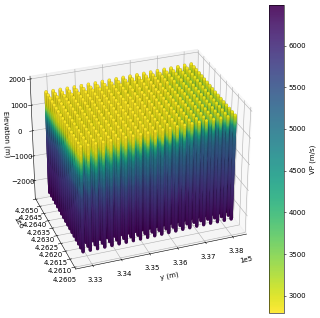

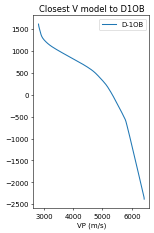

In [3]:
#%%% Velocity model
# =============================================================================
P_or_S='P'
# P_or_S='S'

# The Vp and Vs model (Forge3D_velo5D_float_01312018.sgy)seems to have an offset. I have to add these v discrepancies to match the observed arrivals.  
if P_or_S=='P':
    vp_discrepency=1200 # m/s # The Vp model seems to be 1.2 km/s slower than the obsered arrivals
elif P_or_S=='S':
    vp_discrepency=-1200 # m/s # I can match the S wave arrivals if I subtract 1.2 km/s from the Vp model
else:
    raise "P or S ???!!!"


plot_model=True
# Path of the velocity file
vel_file=os.path.join(opda_dir,'models','Forge3D_velo5D_float_01312018.sgy')

# =============================================================================


z_spacing=20 # Spacing of the data points
st = _read_segy(vel_file, unpack_trace_headers=True)
x_coords_vmodel=np.array([tr.stats.segy.trace_header['group_coordinate_x'] for tr in st])
y_coords_vmodel=np.array([tr.stats.segy.trace_header['group_coordinate_y'] for tr in st])
elevations_vmodel=np.array([tr.stats.segy.trace_header['receiver_group_elevation'] for tr in st])
# Initialize
xyzc_coords_vmodel_list=[]
for i,ele in enumerate(elevations_vmodel):
    zs=np.arange(ele,ele-len(st[i].data)*z_spacing,-z_spacing)
    cs=st[i].data+vp_discrepency
    xyzc_coords=[(x_coords_vmodel[i],y_coords_vmodel[i], zs[iz],cs[iz]) for iz in range(len(zs))]  
    xyzc_coords_vmodel_list.extend(xyzc_coords)
xyzc_coords_vmodel_list=np.array(xyzc_coords_vmodel_list)


#%%%% Get the closest velocity model to well D-1OB
def get_closest_vmodel(x,y):
    '''
    Get the closest 1D vertical v profile to easting x and northing y.
    ''' 
    dis=np.linalg.norm(np.stack([x_coords_vmodel,y_coords_vmodel],axis=-1)-\
                                 np.array([np.nanmedian(x),np.nanmedian(y)]),axis=-1)
    
    ind=np.nanargmin(dis)
    print('Horizontal distance between the well and the closest data point: %s m'%dis[ind])
    vp_profile_closest=st[ind].data+vp_discrepency
    ele_for_vp_profile_closest=np.arange(elevations_vmodel[ind],
                                             elevations_vmodel[ind]-len(st[i].data)*z_spacing,
                                             -z_spacing)
    interp_vp_func= interp1d(ele_for_vp_profile_closest,vp_profile_closest, 
                                 kind='linear', fill_value='extrapolate')
    return interp_vp_func,vp_profile_closest,ele_for_vp_profile_closest

interp_vp_func_1OB,vp_profile_closest_1OB,ele_for_vp_profile_closest_1OB=get_closest_vmodel(x_1OB,y_1OB)


if plot_model:
    # (Plot) The loaded velocity model
    # =============================================================================
    sep=1
    # =============================================================================

    fig = plt.figure(figsize=[8,8])

    x=xyzc_coords_vmodel_list[::sep,0]
    y=xyzc_coords_vmodel_list[::sep,1]
    z=xyzc_coords_vmodel_list[::sep,2]#/0.3048
    c=xyzc_coords_vmodel_list[::sep,3]
    
    ax = fig.add_subplot(111, projection='3d')
    s1=ax.scatter(x,y,z, c=c, marker='o',alpha=0.9,cmap='viridis_r',edgecolors='k',lw=0.1)
    plt.xlabel('x (m)')
    plt.xlabel('y (m)')
    ax.set_zlabel('Elevation (m)')
    # Equal aspect ratio
    world_limits = ax.get_w_lims()
    ax.set_box_aspect((world_limits[1]-world_limits[0],world_limits[3]-world_limits[2],world_limits[5]-world_limits[4]))
    
    ax.view_init(30,250)
    ax.ticklabel_format(axis='x', style='sci',scilimits=(0,0))
    cbar=plt.colorbar(s1,pad=0.01)
    cbar.ax.set_ylabel('V%s (m/s)'%P_or_S)
    plt.show()

    fig,ax=plt.subplots(figsize=[3,5])
    x=vp_profile_closest_1OB
    y=ele_for_vp_profile_closest_1OB
    plt.plot(x,y,label='D-1OB')
    plt.legend()
    plt.xlabel('V%s (m/s)'%P_or_S)

    plt.title('Closest V model to D1OB')
    plt.show()

## Channel information

In [4]:
interp_vp_func=interp_vp_func_1OB # Interpolation function to get vp at each channel
utmX_list,utmY_list,elev_list=x_1OB,y_1OB,z_1OB # Coordinates of channels
vp_profile_well=interp_vp_func(elev_list)

# Distances btw every channel
ch_sep_list = np.sqrt(np.gradient(utmX_list)**2 + np.gradient(utmY_list)**2 + np.gradient(elev_list)**2)
ch_cumsep_list = np.cumsum(ch_sep_list)-np.cumsum(ch_sep_list)[0]
vp_profile_well=interp_vp_func(elev_list)
ref_elev= np.nanmax(elev_list)
dep_list=np.abs(elev_list-ref_elev)


## Read event catalog

Columns in the catalog:
Index(['t0', 'lat', 'lon', 'elevation_m', 'depth_m', 'Mw_surface', 'inj_x_m',
       'inj_y_m', 'inj_z_m', 'strdrop_MPa', 'fc_Hz', 'm0_Nm', 'fc_mad_Hz',
       'm0_mad_Nm', 'Mw_DAS', 'src_radius_m', 'slip_m'],
      dtype='object')
Number of events: 6767


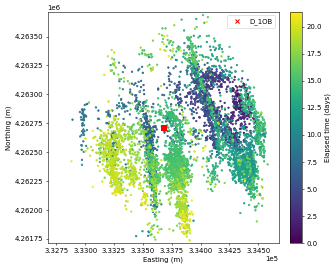

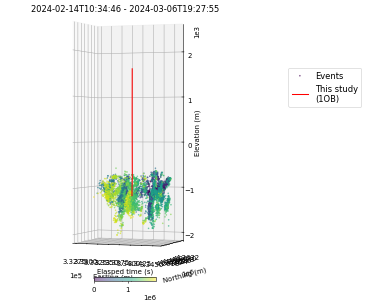

In [5]:
# =============================================================================
plot_events=True
# plot_events=False

# =============================================================================

# Read catalog
infile=os.path.join(opda_dir,'catalog','event_catalog.csv')
cat=pd.read_csv(infile)             
print('Columns in the catalog:')
print(cat.columns)
print('Number of events:',len(cat))

cat['easting']=cat.apply(lambda row: utm.from_latlon(row['lat'], row['lon'])[0],axis=1) 
cat['northing']=cat.apply(lambda row: utm.from_latlon(row['lat'], row['lon'])[1],axis=1)  
cat['evid']=cat.apply(lambda row: UTCDateTime(row['t0']).strftime('%Y%m%d%H%M%S_%f'),axis=1)

cat_t0_list=np.array([UTCDateTime(cat['t0'].values[i]) for i in range(len(cat))])
cat_elapsed_time_list=cat_t0_list-min(cat_t0_list)

cat_dep_list=cat['depth_m'].values
cat_UTMx_list=cat['easting'].values
cat_UTMy_list=cat['northing'].values
cat_lat_list=cat['lat'].values
cat_lon_list=cat['lon'].values
cat_ele_list=cat['elevation_m'].values

if plot_events:

    #% (Plot) MS and wells
    x=cat_UTMx_list
    y=cat_UTMy_list
    s=5
    c=cat_elapsed_time_list/86400
    fig=plt.figure(figsize=[10,6])
    
    ax = plt.gca()
    s1=ax.scatter(x,y,s=s,c=c)
    p1=ax.scatter(x_1OB,y_1OB,color='r',marker='x',label='D_1OB')
    plt.xlabel('Easting (m)')
    plt.ylabel('Northing (m)')
    ax.set_aspect('equal')
    
    ax.ticklabel_format(axis='both', style='sci',scilimits=(0,0))
    cbar=plt.colorbar(s1,ax=ax,pad=0.03)#,shrink=0.3,pad=0.1,aspect=8)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label('Elapsed time (days)')
    colors=['b','yellow','magenta']
    plt.legend()#bbox_to_anchor=[1.8,0.5])
    ax.set_xlim(np.nanmedian(x_1OB)-1000,np.nanmedian(x_1OB)+1000)
    ax.set_ylim(np.nanmedian(y_1OB)-1000,np.nanmedian(y_1OB)+1000)
    
    plt.show()
    
    
    #%%%% (Plot) Wells & EQs
    
    # =============================================================================
    # xy_bdry=500
    z_bdy=1000
    equal_aspect=True
    # equal_aspect=False
    
    ch_num_1OB=1600 # The first dimension of 1OB data
    s=2
    
    # =============================================================================
    
    fig=plt.figure(figsize=[8,8])
    ax=plt.axes(projection='3d')
    
    x,y,z=cat_UTMx_list, cat_UTMy_list, cat_ele_list
    s1=ax.scatter(xs=x,ys=y,zs=z,s=s,label='Events',c=cat_elapsed_time_list,alpha=0.5)
    
    x1,y1,z1=x_1OB,y_1OB,z_1OB
    plt.plot(x1,y1,z1,label='This study\n(1OB)',color='r',zorder=5)
    plt.legend(bbox_to_anchor=[1.5,0.8],fontsize=12)
    
    ax.set_xlim(np.nanmin(x1)-1000,np.nanmax(x1)+1000)
    ax.set_ylim(np.nanmin(y1)-1000,np.nanmax(y1)+500)
    ax.set_zlim(np.nanmin(z1)-z_bdy,np.nanmax(z1)+z_bdy)
    plt.xlabel('Easting (m)')
    plt.ylabel('Northing (m)')
    ax.set_zlabel('Elevation (m)')
    # world_limits 
    # Equal aspect ratio
    if equal_aspect:
        world_limits = ax.get_w_lims()
        ax.set_box_aspect((world_limits[1]-world_limits[0],
                           world_limits[3]-world_limits[2],
                           world_limits[5]-world_limits[4]))
    
    ax.ticklabel_format(axis='both', style='sci',scilimits=(0,0))
    cbar=plt.colorbar(s1,ax=ax,pad=0.07,shrink=0.2,aspect=16,orientation='horizontal')
    cbar.ax.tick_params(labelsize=10)
    cbar.ax.set_title('Elasped time (s)',fontsize=10)
    # =============================================================================
    ax.view_init(0, 290, 0)
    
    # =============================================================================
    ax.set_title('%s - %s'%(min(cat_t0_list).strftime('%Y-%m-%dT%H:%M:%S'),
                            max(cat_t0_list).strftime('%Y-%m-%dT%H:%M:%S')))
    plt.show()


# Spectral ratio (one event)

## Read spectra

In [40]:
# =============================================================================
iev=1466 # Select one event in the iev_list_for_att list


# =============================================================================

In [41]:

# =============================================================================
# For loading the data
which_well='1OB'
# Folder that contains the incident angles for each channel of each event 
inc_angle_dir=os.path.join(opda_dir,'catalog','tt_inc_%s'%P_or_S)
# Folder that contains the travel times for each channel of each event 
tt_dir=os.path.join(opda_dir,'catalog','tt_inc_%s'%P_or_S)
# Folder that contains the arrival picks for each channel of each event 
arr_dir=os.path.join(opda_dir,'catalog','arr_picks_%s'%P_or_S)
# Folder that contains the waveform file for each channel of each event 
wf_dir=os.path.join(opda_dir,'waveforms','phase_%s'%P_or_S)
# Folder that contains the accumulated attenuation files for each channel of each event 
att_dir=os.path.join(opda_dir,'catalog','accum_att_%s'%P_or_S)

# =============================================================================

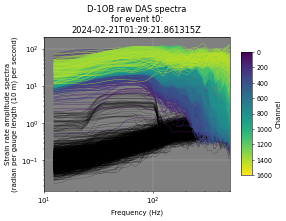

In [42]:
# =============================================================================
show_plot=True

# =============================================================================
cat_target=cat.iloc[iev]                    # Target event catalog
t0=UTCDateTime(cat_target['t0'])                        # Origin time
evid=t0.strftime('%Y%m%d%H%M%S_%f') # evid is formatted using t0
infile=os.path.join(opda_dir,'spectra','spec_D-1OB_%s_arr_%s.npz'%(P_or_S,evid))
r=np.load(infile,allow_pickle=True)                   # Read spectra file
ch_list_partial=r['ch_list_partial'] # Selected channels with good picks
spec_list_partial=r['spec_list_partial']   # P-arrival of raw DAS spectra of selected channels
spec_n_list_partial=r['spec_n_list_partial'] # Noise of raw DAS spectra (0.3 s before the signal window) of selected channels 
f_series=r['f_series'] # Frequency
num_all_ch=1600 # Number of channels in D-1B
fst=1000 # Sampling rate (Hz)
twin=0.1 # Time window for calculating the spectra


#mag=cat_target['DAS_Mw']
cat_ele_list[iev]

# Event coordinates
elev_z_src=cat_target['elevation_m']
utm_x_src=cat_target['easting']
utm_y_src=cat_target['northing']
src_ch=rec_list[np.nanargmin(abs(elev_list-elev_z_src))] # Channel that is the closest to the source elevation
src_vp=float(interp_vp_func(elev_z_src)) # Vp at src depth



# Load accumulated attenuation
load_filename=os.path.join(att_dir,'accum_att_%s_well%s_id%s.npy'%(
    P_or_S,which_well,ev_id))
att_list=np.load(load_filename)

# Load incident angle 
load_filepath_inc_angle=os.path.join(inc_angle_dir,'inc_angles_rad_%s_well%s_id%s.npy'%(P_or_S,which_well,ev_id))
inc_angles_list=np.load(load_filepath_inc_angle)

# Load travel time 
load_filename=os.path.join(tt_dir,'travel_times_%s_well%s_id%s.npy'%(P_or_S,which_well,ev_id))
if not os.path.exists(load_filename):
    raise FileNotFoundError('No travel time file.')
    # print('No travel time for iev:',iev)
    # bad_iev_list.append(iev)
    # continue
tt_list=np.load(load_filename)

# Load arrival picks (for calculating apparent velocity. Can also derive it from theoretical travel time)
arr_infile=os.path.join(arr_dir,'arr_picks_%s_evid%s.npz'%(which_well,ev_id))
if not os.path.exists(arr_infile):
    raise FileNotFoundError('No arrival pick file.')
r=np.load(arr_infile)
arr_picks=r['arr_picks_fil']

# #%%% Calculate smoothed apparent velocity
# =============================================================================
window_size=100
# =============================================================================
x=ch_cumsep_list 
y=arr_picks
y1=ut.moving_average_smoothing(series=y, window_size=window_size)
y2=np.convolve(y1, np.ones(window_size)/window_size, mode='same')
y3=ch_sep_list/(-np.gradient(y2))
app_vp_list=np.convolve(y3, np.ones(window_size)/window_size, mode='same')
    

vec=np.stack([utmX_list,utmY_list,elev_list],axis=-1)-np.array([utm_x_src,utm_y_src,elev_z_src])
dis_m_list=np.linalg.norm(vec,axis=-1) # Straight line hypocentral distance 
chs_nan=np.where(np.isnan(dis_m_list))[0]
chs_valid=np.where(~np.isnan(dis_m_list))[0]

def pad_data_2_correct_channel_number(data_partial,ch_partial,num_all_ch):
    '''
    The spectra files only contain data of selected channels.
    This function pads nans to non-selected channels for the loaded data so that 
    the data sizes are the same for all events: (number of DAS channels in D-1OB 
                                                 (1600), number of time samples)
    
    '''
    # Initialize
    data_full=np.full([num_all_ch, data_partial.shape[1]], np.nan)
    data_full[ch_partial]=data_partial
    return data_full

spec_list=pad_data_2_correct_channel_number(spec_list_partial,ch_list_partial,num_all_ch)
spec_n_list=pad_data_2_correct_channel_number(spec_n_list_partial,ch_list_partial,num_all_ch)  



if show_plot:

    x=f_series
    y1=spec_list
    y2=spec_n_list
    
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(y1)) for i in range(len(y1))]
    
    fig,ax=plt.subplots(figsize=[6,4])
    ax.set_facecolor('gray')
    # Initialize
    spec_all_stack=[]
    for ist in range(len(y1)):
        # ch=mid_ch_list[ist]
        
        indsort=np.argsort(x)
        ax.semilogy(x[indsort],
                    y1[ist][indsort],color=colorst[ist],lw=0.5,zorder=5)
    
        ax.semilogy(x[indsort],
                    y2[ist][indsort],color='k',lw=0.2,zorder=4)        
    
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Strain rate amplitude spectra\n(radian per gauge length (10 m) per second)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(lw=0.5)
    ax.set_xlim(1/twin,fst/2)
    plt.title('D-1OB raw DAS spectra\nfor event t0:\n%s'%(t0))
    norm = mpl.colors.Normalize(vmin=0, vmax=len(colorst))
    cmap=plt.get_cmap("viridis", len(colorst))
    sm = plt.cm.ScalarMappable(norm=norm, cmap=colormap)
    cbar=fig.colorbar(sm,shrink=0.8,aspect=12,ax=ax)
    cbar.ax.invert_yaxis()
    cbar.ax.set_ylabel('Channel')
    cbar.ax.tick_params(labelsize=9)
    
    plt.show()


## Flat response and unit conversion

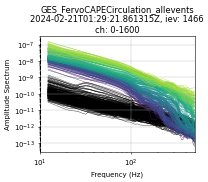

In [43]:
# =============================================================================
# Choose whether using velocity from vmodel or apparent velocity from picking to 
# estimate the flat response. Does not produce significantly different results.
unit_conversion_via_vapp_or_v='v' 


show_plot=True
# =============================================================================
#%%% Convert to displacement
if unit_conversion_via_vapp_or_v=='vapp':
    rawDAS2acc_factor=ut.rawDAS2acc_factor_via_vapp
    x=app_vp_list
elif unit_conversion_via_vapp_or_v=='v':
    rawDAS2acc_factor=ut.rawDAS2acc_factor_via_v  
    x=vp_profile_well
else:
    raise "vapp or v ??!!"
    
    
spec_list=spec_list*(rawDAS2acc_factor(
                    x[:,np.newaxis],inc_angles_list[:,np.newaxis],P_or_S))
spec_list=np.abs(spec_list/((2j*np.pi*f_series)**2))/1e9

spec_n_list=spec_n_list*rawDAS2acc_factor(
                    x[:,np.newaxis],inc_angles_list[:,np.newaxis],P_or_S)
spec_n_list=np.abs(spec_n_list/((2j*np.pi*f_series[np.newaxis,:])**2))/1e9  


if show_plot:
    #%%% (Plot) spectra: signal vs noise
    
    # =============================================================================
    ch_min=0
    ch_max=1600

    # =============================================================================

    colormap = plt.cm.viridis
    colorst = [colormap(i/len(spec_list)) for i in range(len(spec_list))]
    
    indsort=np.argsort(f_series)
    fig,ax=plt.subplots(figsize=[4,3])
    
    # Initialize
    spec_stack=[]
    
    for ist in range(len(spec_list)):
        
    # =============================================================================
        y1=spec_list[ist]
        y_n1=spec_n_list[ist]
    # =============================================================================
        
    
        if ist>ch_min and ist<ch_max and ist%5==0:
    
            ax.semilogy(f_series[indsort],y1,color=colorst[ist],lw=0.5,zorder=5)
            ax.semilogy(f_series[indsort],y_n1,
                        'k',
                        lw=0.5,zorder=1)
            
            spec_stack.append(spec_list[ist][indsort])
        
            # ax.semilogy(f_series[indsort],specs[ist][indsort]/specs_n[ist][indsort],color=colorst[ist],lw=0.5,zorder=5)
            spec_stack.append(spec_list[ist][indsort]/spec_n_list[ist][indsort])
    
            
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude Spectrum')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(lw=0.5)
    ax.axvline(x=1/twin,ls='--',color='k')
    ax.axvline(x=fst/2,ls='--',color='k')
    ax.set_xlim(10,fst/2)
    
    # ax.set_ylim(0.1,2000)
    # ax.set_ylim(1e-3,1e5)
    plt.title('GES_FervoCAPECirculation_allevents\n%s, iev: %s'%(t0,iev)+'\nch: %s-%s'%(ch_min,min(ch_max,len(spec_list))))
    plt.show()

## SNR threshold and resample

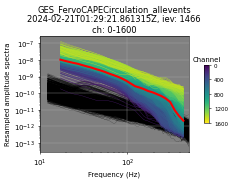

In [44]:
# #%%% (Thr) f range (fmax, fmin)
# =============================================================================
loglog_or_loglinear='loglog' # Resample in which space? For Brune's model fitting, use loglog

snr_limit = 3#*3
show_plot=True
# =============================================================================
# Initialize
fmin_list   = np.zeros(shape=len(spec_list),dtype=float)
fmax_list   = copy(fmin_list )


for i in range(len(spec_list)):
    
    if all(np.isnan(spec_list[i])):
        fmin_list[i], fmax_list[i]=np.nan, np.nan
        continue
    else:
        r = ut.get_f_range_EV(
                spec_list[i], spec_n_list[i],
                f_series, fst, snr_limit)
    
        # Unpack the results
        fmin_list[i], fmax_list[i] = r['fmin'], r['fmax']
        
if loglog_or_loglinear=='loglog':
    #### Log resample (spec_resamp, f_resamp)
    # =============================================================================
    deltaf = 0.05 # in log unit
    nsec = twin
    
    # Maximum available frequency range:
    # lowf_min = 1/nsec # 
    lowf_min=np.nanmin(fmin_list)
    lowf_min
    
    y=spec_list; which_spec='acc'
    # y=specD_list/specD_n_list ; which_spec='dis/dis_n'
    # =============================================================================
    
    highf_max = fst/2 *0.8
    # Initialize
    specs_resamp =[]
    f_resamp = []
    
    for i,sr in enumerate(y):
        f, s  = ut.log_resample( y[i], f_series, np.log10(lowf_min), np.log10(highf_max), deltaf)
        specs_resamp.append(s)
        f_resamp.append(f)
        
    # f_series
    specs_resamp = np.asarray(specs_resamp)
    f_resamp=np.asarray(f_resamp[0])
    f2=f_resamp
    
    # Set part that is outside the f range to nan
    for i, f in enumerate(f_resamp):
        specs_resamp[i] = np.where(f< fmin_list[i], np.nan, specs_resamp[i] )
        specs_resamp[i] = np.where(f> fmax_list[i], np.nan, specs_resamp[i] )
        
    specs_QC=specs_resamp
    
elif loglog_or_loglinear=='loglinear':

    # Set part that is outside the f range to nan
    for i, f in enumerate(f_series):
        spec_list[i] = np.where(f< fmin_list[i], np.nan, spec_list[i] )
        spec_list[i] = np.where(f> fmax_list[i], np.nan, spec_list[i] )        
    specs_QC=spec_list
    f2=f_series

if show_plot:
   # #%%%% (Plot) resampled spec 
    # =============================================================================
    ch_min=0
    ch_max=1600
    
    # =============================================================================
    # np.count_nonzero(specs_resamp.ravel())
    c=specs_QC
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(c)) for i in range(len(c))]
    fig,ax=plt.subplots(figsize=[5,3])
    ax.set_facecolor('gray')
    # Initialize
    stacked_specs_QC=[]
    for ist in range(len(c)):
        # if ist%10==0:
        if ist>ch_min and ist<ch_max:
            ax.semilogy(f2,c[ist],color=colorst[ist],lw=0.5,zorder=5)
            stacked_specs_QC.append(c[ist])
            
            ax.semilogy(f_series[indsort],spec_n_list[ist][indsort],
                        'k',
                        # color=colorst[ist],
                        lw=0.2,zorder=1)
    stacked_specs_QC=np.nanmedian(stacked_specs_QC,axis=0)
    ax.semilogy(f2,stacked_specs_QC,'r',lw=3,zorder=6)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Resampled amplitude spectra')
    # ax.set_ylim(0.5e0,2e1)
    # ax.set_ylim(20,1000)
    ax.set_xlim(10,500)
    if loglog_or_loglinear=='loglog':
        ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(lw=0.5)
    plt.title('GES_FervoCAPECirculation_allevents\n%s, iev: %s'%(t0,iev)+'\nch: %s-%s'%(ch_min,min(ch_max,len(specs_QC))))

    norm = mpl.colors.Normalize(vmin=0, vmax=len(rec_list))
    cb1=fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=colormap),ax=ax,shrink=0.5,aspect=12,pad=0.08)
    
    cb1.ax.invert_yaxis()
    cb1.ax.set_ylim([ch_max,ch_min])
    cb1.ax.set_title('Channel',fontsize=10)
    cb1.ax.tick_params(labelsize=8
                       )
    cb1.ax.set_yticks(np.arange(0,len(rec_list)+1,400))
        
    plt.show()

## Calculate gauge length effects

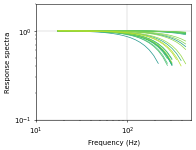

In [45]:

# #%%% Instrument response for selected channels
# =============================================================================
# Response with amplitude lower than the water level is removed to np.nan to prevent amplifying noise.
water_level=4e-1

# Spectra with cutoff frequency (the frequency at which the response spectra drop below the water level) less then lowest_fmax_above_water_level will be completely removed (bad channel).
lowest_fmax_above_water_level=200
plot_response=True
# =============================================================================

# Initialize
resp_list=np.full((len(rec_list),len(f2)),np.nan)
upper_f_list=np.full(len(rec_list),np.nan)
for i in range(len(rec_list)):
    v_app=app_vp_list[i]
    resp=ut.gauge_length_effect_spectra(f=f2,app_vp=v_app,L=gaugeLength)


    if all(np.isnan(resp)):
        continue
    ind=np.where(resp>water_level)[0]
    try:
        upper_f=f2[ind[-1]]
        upper_f_list[i]=upper_f
        if upper_f<lowest_fmax_above_water_level:
            resp_list[i,:]=np.nan
        else:
            resp=np.where(resp>water_level,resp,np.nan)
            resp_list[i,:]=resp
    except IndexError: # index -1 is out of bounds for axis 0 with size 0
        upper_f_list[i]=np.nan
        resp_list[i,:]=np.nan

if plot_response:
    #%%%% (Plot) Response (for MIT thesis)    
    yy=resp_list
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(yy)) for i in range(len(yy))]
    fig,ax=plt.subplots(figsize=[4,3])
    for i,y in enumerate(yy):
        if i>ch_min and i<ch_max and i%20==0:
            ax.semilogy(f2,y,color=colorst[i],lw=1,zorder=5)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Response spectra')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(lw=0.5)
    ax.set_xlim(10,fst/2)
    ax.set_ylim(1e-1,2e0)
        
    plt.show()

## Remove gauge length effects

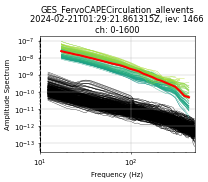

In [46]:
specs_QC_rmresp=specs_QC/resp_list

if show_plot:

    # #%%% Remove instrument response
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(specs_QC)) for i in range(len(specs_QC))]
    
    fig,ax=plt.subplots(figsize=[4,3])
    # Initialize
    spec_QC_rmresp_stack=[]
    
    for ist in range(len(specs_QC)):
        resp=resp_list[ist]

        if ist>ch_min and ist<ch_max and ist%5==0:
            
            y=(specs_QC[ist]/resp)#[indsort]
            ax.semilogy(f2,y,color=colorst[ist],lw=0.5,zorder=5)
            ax.semilogy(f_series,spec_n_list[ist],#[indsort],
                        'k',
                        # color=colorst[ist],
                        lw=0.5,zorder=1)
            spec_QC_rmresp_stack.append(y)
    ax.semilogy(f2,np.nanmedian(spec_QC_rmresp_stack,axis=0),'r',lw=3,zorder=6)
            
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude Spectrum')

    if loglog_or_loglinear=='loglog':
        ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(lw=0.5)
    ax.axvline(x=1/twin,ls='--',color='k')
    ax.axvline(x=fst/2,ls='--',color='k')
    ax.set_xlim(10,fst/2)
    # ax.set_ylim(0.1,2000)
    # ax.set_ylim(1e-3,1e5)
    plt.title('GES_FervoCAPECirculation_allevents\n%s, iev: %s'%(t0,iev)+'\nch: %s-%s'%(ch_min,min(ch_max,len(specs_QC))))
    plt.show()




## Stack nearby channels

/tmp/ipykernel_4190591/3462374509.py:38: RuntimeWarning: All-NaN slice encountered
  spec_stack=np.nanmedian(specs[ch0:ch1,:],axis=0)


Number of stacks: 60


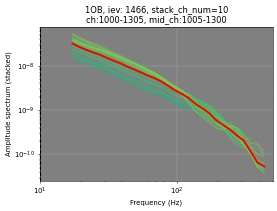

In [47]:
#%%% Stack spectra 
# =============================================================================\

# Select a channel range with good SNR 
# (Can also try to use all channels and filter later)
ch_min=1000
ch_max=1300
    
stack_ch_num=10 # How many channel in one stack
stack_ch_step=5 # How the window step along the fiber


show_plot=True
# =============================================================================

ch0_list=np.arange(ch_min,ch_max,stack_ch_step)
specs=specs_QC_rmresp


# Initialize
spec_stacks=[]
# spec_n_stacks=[]
ch1=0
i=0
mid_ch_list=[] 
mid_elev_list=[]
mid_dis_m_list=[]
mid_vp_list=[] # Median vp in the structure
mid_app_vp_list=[] # Median apparent vp of this event
mid_att_list=[]

mid_fmin_list=[]
mid_fmax_list=[]

indsort=np.argsort(f_resamp)
for ch0 in ch0_list:
    ch1=ch0+stack_ch_num
    spec_stack=np.nanmedian(specs[ch0:ch1,:],axis=0) 
    # spec_n_stack=np.nanmedian(spec_n[ch0:ch1,:],axis=0) 
    mid_elev=np.nanmedian(elev_list[ch0:ch1],axis=0) 
    mid_dis_m=np.nanmedian(dis_m_list[ch0:ch1],axis=0) 
    mid_vp=np.nanmedian(vp_profile_well[ch0:ch1],axis=0) 
    mid_app_vp=np.nanmedian(app_vp_list[ch0:ch1],axis=0) 
    mid_att=np.nanmedian(att_list[ch0:ch1],axis=0) 
    
    try:
        ind=np.where(~np.isnan(spec_stack))[0][0]
        mid_fmin=f_resamp[ind] # Would have error if f_resamp is not in order
    except IndexError:
        mid_fmin=np.nan    
    try:
        ind=np.where(~np.isnan(spec_stack))[0][-1]
        mid_fmax=f_resamp[ind] # Would have error if f_resamp is not in order
    except IndexError:
        mid_fmax=np.nan
    spec_stacks.append(spec_stack)
    # spec_n_stacks.append(spec_n_stack)
    mid_ch_list.append((ch0+ch1)//2)
    mid_elev_list.append(mid_elev)
    mid_dis_m_list.append(mid_dis_m)
    mid_vp_list.append(mid_vp)
    mid_app_vp_list.append(mid_app_vp)
    mid_att_list.append(mid_att)
    mid_fmin_list.append(mid_fmin)
    mid_fmax_list.append(mid_fmax)
    
    
spec_stacks=np.array(spec_stacks)
# spec_n_stacks=np.array(spec_n_stacks)
mid_ch_list=np.array(mid_ch_list)
mid_elev_list=np.array(mid_elev_list)
mid_dis_m_list=np.array(mid_dis_m_list)
mid_vp_list=np.array(mid_vp_list)
mid_app_vp_list=np.array(mid_app_vp_list)
mid_tt_list=mid_dis_m_list/mid_vp_list
mid_att_list=np.array(mid_att_list)
mid_fmin_list=np.array(mid_fmin_list)
mid_fmax_list=np.array(mid_fmax_list)


print('Number of stacks:',len(mid_ch_list))

spec_stacks=np.where(spec_stacks>0,spec_stacks,np.nan)

if show_plot:
    
    #%%% (Plot) stack spectra: signal vs noise
       
    y1=spec_stacks
    # y2=spec_n_stacks
    colormap = plt.cm.viridis
    colorst = [colormap(i/len(rec_list)) for i in range(len(rec_list))]
    indsort=np.argsort(f_resamp)
    indsort_n=np.argsort(f_series)
    fig,ax=plt.subplots(figsize=[6,4])
    ax.set_facecolor('gray')
    # Initialize
    spec_all_stack=[]
    for ist in range(len(y1)):
        ch=mid_ch_list[ist]
        if ch>ch_min and ch<ch_max:
            ax.semilogy(f_resamp[indsort],y1[ist][indsort],color=colorst[ch],lw=0.5,zorder=5)
            
            # ax.semilogy(f_series[indsort_n],y2[ist][indsort_n],'k',lw=0.2,zorder=1)
            
            spec_all_stack.append(y1[ist][indsort])
    ax.semilogy(f_resamp[indsort],np.nanmedian(spec_all_stack,axis=0),'r',lw=3,zorder=6)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Amplitude spectrum (stacked)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.grid(lw=0.5)
    ax.axvline(x=1/twin,ls='--',color='k')
    ax.axvline(x=fst/2,ls='--',color='k')
    ax.set_xlim(10,fst/2)
    
    plt.title('%s, iev: %s, stack_ch_num=%d\nch:%s-%s, mid_ch:%s-%s'%(
        which_well,iev,stack_ch_num,ch0_list[0],ch0_list[-1]+stack_ch_num,mid_ch_list[0],mid_ch_list[-1]))
    
    plt.show()

## Fit Brune's model

In [48]:
#%%% Fit
# =============================================================================
n_fit=2 # Assume high frequency fall-off rate (do not recommend changing if you do not know what it is)
gamma_fit=1 # Assume Brune (1) or Boatwright (2) model (Can change to see which one fits better)
low_f_lv_for_Omega0=25 # I will take the average amp below this frequency as the initial guess for Omega0
Omega0_factor=1e-15 # Do not change this. This is a temporary scaling factor in the fitting process to circumvent the inability of lmfit to analyze small numbers. If you encouter error related to Omega0_range, try lowering this number (to the same magnitude range of the data) 

fc_range=(20,400) # The range of possible fc values
fit_f_range=(20,400) # Only minimize residuals in this frequency range

# =============================================================================
# Initialize
fc_list=np.repeat(np.nan,len(mid_ch_list))
Omega0_list=np.repeat(np.nan,len(mid_ch_list))
stderr_fc_list=np.repeat(np.nan,len(mid_ch_list))
stderr_Omega0_list=np.repeat(np.nan,len(mid_ch_list))
resid_sum_list=np.repeat(np.nan,len(mid_ch_list))
chisqr_list=np.repeat(np.nan,len(mid_ch_list))
redchi_list=np.repeat(np.nan,len(mid_ch_list))

for i in range(len(mid_ch_list)):
    # Need to scale Omega0 up otherwise can't fit properly
    x=np.array(f_resamp)
    y=np.array(spec_stacks[i])
    
    if all(np.isnan(y)) or all(np.isnan(y[np.where(x<low_f_lv_for_Omega0)[0]])):
        fc_list[i]=np.nan
        Omega0_list[i]=np.nan
        stderr_fc_list[i]=np.nan
        stderr_Omega0_list[i]=np.nan
    else:
        print(i)

            
        result,mini = ut.fit_spec_single_att(
            x=x,
            y=y/Omega0_factor,
            att=mid_att_list[i],            
        # =============================================================================
            init_fc=100,
            low_f_lv_for_Omega0=low_f_lv_for_Omega0,
            gamma=gamma_fit,
            n=n_fit,
            fc_range=fc_range,
            Omega0_range=None,
            method='least_squares',
            nan_policy='omit',
            print_reports=False,
            fmin=fit_f_range[0], fmax=fit_f_range[1]
            )
        # =============================================================================
        if result.params['Omega0'].stderr ==None:
            fc_list[i]=np.nan
            Omega0_list[i]=np.nan
            stderr_fc_list[i]=np.nan
            stderr_Omega0_list[i]=np.nan
            continue
        else:
            stderr_Omega0=result.params['Omega0'].stderr*Omega0_factor
            stderr_fc=result.params['fc'].stderr
            Omega0=result.params['Omega0'].value*Omega0_factor
            fc=result.params['fc'].value
            cv_fc=stderr_fc/fc*100
            cv_Omega0=stderr_Omega0/Omega0*100
            # results_list.append(result)
            resid_sum_list[i]=np.sum(abs(result.residual))
            chisqr_list[i]=result.chisqr
            redchi_list[i]=result.redchi
            
            fc_list[i]=result.params['fc'].value
            Omega0_list[i]=Omega0
            stderr_fc_list[i]=stderr_fc
            stderr_Omega0_list[i]=stderr_Omega0


unc_fc_list=np.array([stderr_fc_list[i]/fc_list[i]*100 for i in range(len(fc_list))])


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


In [49]:
#%%% Filter boundary values

# =============================================================================
# Define bad values
# cond=np.array([~(np.log10(fc_list)<np.log10(fmax)*0.90 and np.log10(fc)>np.log10(fmin)*1.1) for (fmin, fmax,fc) in zip(mid_fmin_list,mid_fmax_list,fc_list)])

# cond=~((fc_list<fc_range[1]-1)&(fc_list>fc_range[0])& (redchi_list<0.1)&(stderr_fc_list<50) & [(np.log10(fc)<np.log10(fmax)*0.9 and np.log10(fc)>np.log10(fmin)*1.1) for (fmin, fmax,fc) in zip(mid_fmin_list,mid_fmax_list,fc_list)])

# cond=~((fc_list<fc_range[1]-1)&(fc_list>fc_range[0])& (redchi_list<0.05)&((stderr_fc_list/fc_list)<1) & [(np.log10(fc)<np.log10(fmax)*0.9 and np.log10(fc)>np.log10(fmin)*1.1) for (fmin, fmax,fc) in zip(mid_fmin_list,mid_fmax_list,fc_list)])

# cond=~((fc_list<fc_range[1]-1)&(fc_list>fc_range[0])& (redchi_list<0.05)&((stderr_fc_list/fc_list)<1) & [(fc<fmax*0.8 and fc>fmin*1.2) for (fmin, fmax,fc) in zip(mid_fmin_list,mid_fmax_list,fc_list)])

cond=~((fc_list<fc_range[1]-1)&(fc_list>fc_range[0])& (redchi_list<0.02)&((stderr_fc_list/fc_list)<1) & [(fc<fmax*0.8 and fc>fmin*1.2) for (fmin, fmax,fc) in zip(mid_fmin_list,mid_fmax_list,fc_list)])

# =============================================================================
ind=np.where(cond)[0]
fc_list[ind]=np.nan
Omega0_list[ind]=np.nan
stderr_fc_list[ind]=np.nan
stderr_Omega0_list[ind]=np.nan


## Plots

### (Plot) fc results of all stacks for this event

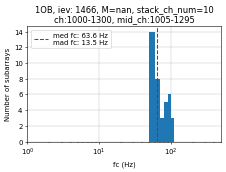

In [50]:
#%%% (Plot) fc 
# =============================================================================
which_to_plot='fc'
# which_to_plot='m0'

# Only plot this channel range
chmin=1000
chmax=1300

# =============================================================================

cond= (mid_ch_list>chmin )&(mid_ch_list<chmax)
ind=np.where(cond)[0]
if which_to_plot=='fc':
    x=fc_list[ind]
    label='med fc: %.01f Hz'%np.nanmedian(x)+'\n'+\
        'mad fc: %.01f Hz'%scipy.stats.median_abs_deviation(x,axis=-1,nan_policy='omit')
    xlim=[1,500]
    xlabel='fc (Hz)'
elif which_to_plot=='m0':
    x=ut.m02Mw(ut.seismic_moment(Omega0=Omega0_list,rho=2790,c=src_vp,R=mid_dis_m_list,Ur=0.52))[ind]
    label='med Mw: %.01f'%np.nanmedian(x)+'\n'+\
        'mad Mw: %.01f'%scipy.stats.median_abs_deviation(x,axis=-1,nan_policy='omit')
    xlim=[None,None]
    xlabel='Mw'    
vm1=np.nanpercentile(x,0)
vm2=np.nanpercentile(x,100)
x=np.where((x>=vm1)&(x<=vm2),x,np.nan)
fig,ax=plt.subplots(figsize=[5,3])
plt.hist(x,  zorder=3,bins=6)#,bins=log_bins)
ax.axvline(np.nanmedian(x),ls='dashed',color='r',
           label=label,zorder=4)
if which_to_plot=='fc':
    ax.set_xscale('log')
plt.xlim(xlim)
plt.grid(True,lw=0.5)
plt.title('%s, iev: %s, M=%.02f, stack_ch_num=%d\nch:%s-%s, mid_ch:%s-%s'%(
    which_well,iev,mag,stack_ch_num,ch0_list[ind][0],ch0_list[ind][-1]+stack_ch_num,mid_ch_list[ind][0],mid_ch_list[ind][-1]))
plt.xlabel(xlabel)
plt.ylabel('Number of subarrays')
plt.legend()

plt.show()


### (Plot) Model fitting

Passing bad value for 16


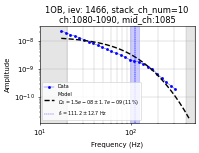

Passing bad value for 17


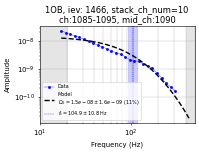

Passing bad value for 18


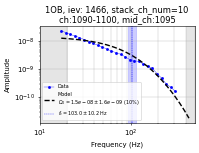

Passing bad value for 19


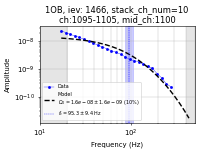

Passing bad value for 20


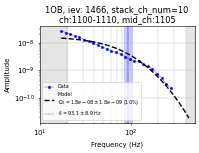

Passing bad value for 21


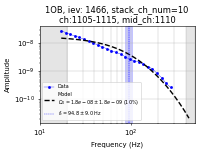

Passing bad value for 22


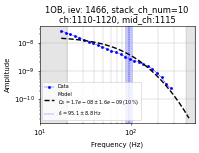

Passing bad value for 23


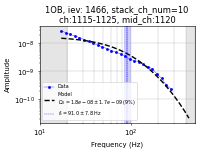

Passing bad value for 24


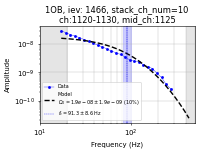

Passing bad value for 25


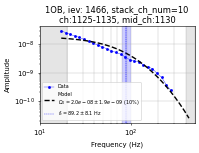

Passing bad value for 26


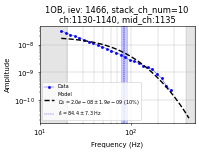

Passing bad value for 27


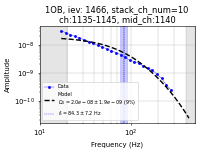

Passing bad value for 28


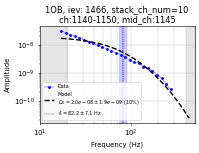

Passing bad value for 29


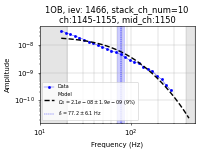

Passing bad value for 30


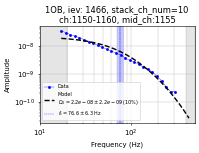

Passing bad value for 31


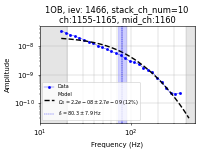

Passing bad value for 33


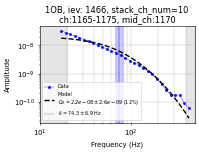

Passing bad value for 34


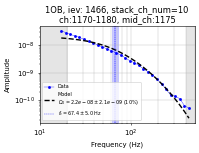

Passing bad value for 35


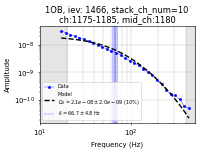

Passing bad value for 36


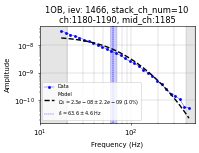

Passing bad value for 37


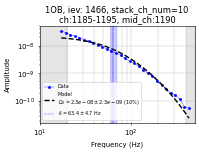

Passing bad value for 38


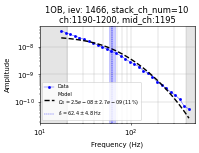

Passing bad value for 39


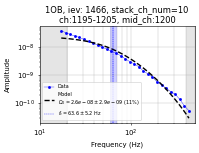

Passing bad value for 40


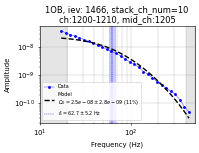

Passing bad value for 41


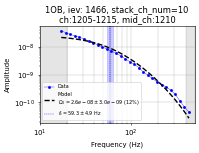

Passing bad value for 42


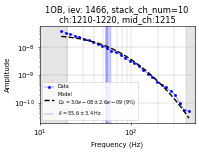

Passing bad value for 43


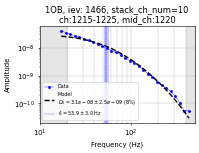

Passing bad value for 44


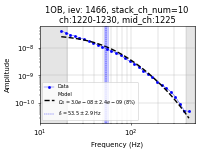

Passing bad value for 45


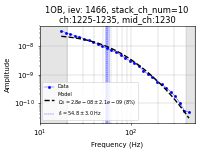

Passing bad value for 46


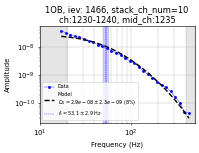

Passing bad value for 47


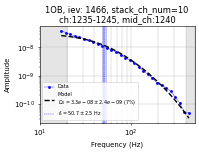

Passing bad value for 48


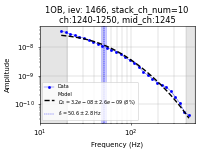

Passing bad value for 49


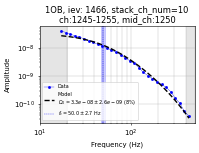

Passing bad value for 50


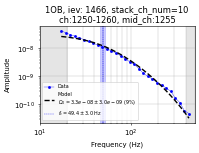

Passing bad value for 51


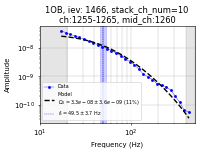

Passing bad value for 52


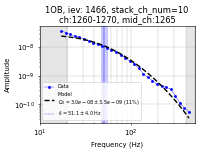

Passing bad value for 53


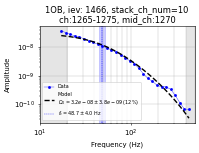

Passing bad value for 54


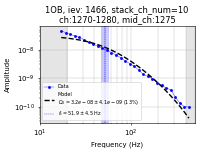

Passing bad value for 55


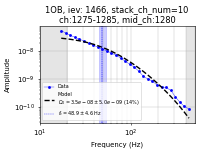

In [52]:
# =============================================================================
# Only plot this channel range
chmin=1000
chmax=1300

# =============================================================================
#%%% (Plot) Fit
x=f_resamp
# ymin,ymax=1,1000
ymin,ymax=None,None

for i in range(len(spec_stacks)):
    # if i==20 or i==125:
    
    if mid_ch_list[i]>chmin and mid_ch_list[i]<chmax:
    # if i%10==0: 
    # if True:
        y=spec_stacks[i]
        fc=fc_list[i]
        if ~np.isnan(fc):
            Omega0=Omega0_list[i]
            stderr_fc=stderr_fc_list[i]
            stderr_Omega0=stderr_Omega0_list[i]
            unc_fc = stderr_fc/fc*100
            unc_Omega0 = stderr_Omega0/Omega0*100
            att=mid_att_list[i]
            
            redchi=redchi_list[i]
            
            # Filter bad values
            cond=((fc<fc_range[1]-1)&(fc>fc_range[0])&(redchi<0.05)&(unc_fc<50))
            if cond:
                print('Passing bad value for %s'%i)
                # print(redchi)
                # print(unc_fc)
                pass
            else:
                continue
            
            fig, ax = plt.subplots(figsize=[4,2.5])
            plt.grid(True)
            label='Model'
            
            color='b'
            plt.loglog(x, y, linewidth=0.5,marker='.',
                       # label='%s'%i,
                       label='Data',
                       color=color)
            plt.loglog(x, ut.spectra_single_att(f=x,fc=fc,Omega0=Omega0,att=att,
            # plt.loglog(x, spectra_single(f=x,fc=fc,Omega0=Omega0,
                                             n=n_fit,gamma=gamma_fit),
                            color='k',linestyle='dashed',
                        linewidth=2,
                        label='Model\n$\Omega_0={:.1e}\pm{:.1e}$ ({:.0f}%)'.format(
                            Omega0,stderr_Omega0,unc_Omega0))
                        # label=label)
            

            plt.axvline(x=fc,linestyle='dashed',linewidth=0.5,color=color)
            
            label=r'$f_c={:.01f}\pm{:.01f}$ Hz'.format(fc,stderr_fc)#+'\n'+'$\Omega_0={:.01f}\pm{:.01f}$'.format(
                # Omega0,err_Omega0)
            plt.axvline(x=fc,linestyle='dashed',linewidth=0.5,color=color,label=label)
            
            # fit_f_range
            plt.ylim(ymin,ymax)
            ax.fill_betweenx(ax.get_ylim(), fc-stderr_fc,fc+stderr_fc,alpha=0.2,
                              color=color)

            plt.xlim(10,500)
            ax.fill_betweenx(ax.get_ylim(), ax.get_xlim()[0],fit_f_range[0],alpha=0.2,
                              color='grey')
            ax.fill_betweenx(ax.get_ylim(), fit_f_range[1],ax.get_xlim()[1],alpha=0.2,
                              color='grey')
            
            ax.set_xlabel("Frequency (Hz)")
            ax.set_ylabel("Amplitude")
            
            
            # plt.ylim(5e-12,2e-9)
            
            plt.grid(which='both',linewidth=0.5,axis='x')
            plt.grid(which='major',linewidth=0.5,axis='y')
            
            # plt.title(mid_ch_list)
            plt.legend(loc='lower left',fontsize=7)
            # ax.legend()
            plt.title('%s, iev: %s, stack_ch_num=%d\nch:%s-%s, mid_ch:%s'%(
                which_well,iev,stack_ch_num,ch0_list[i],ch0_list[i]+stack_ch_num,mid_ch_list[i]))
            plt.show()


## Calculate seismic moment and spectral stress drop

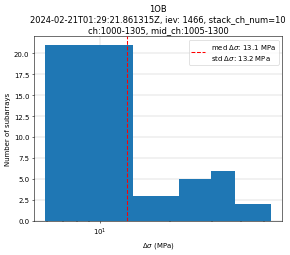

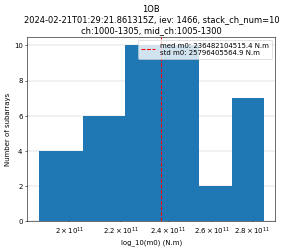

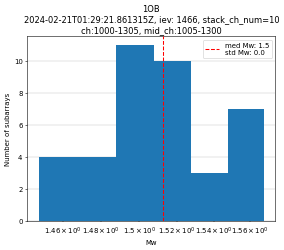

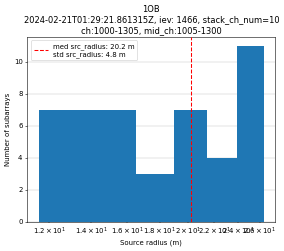

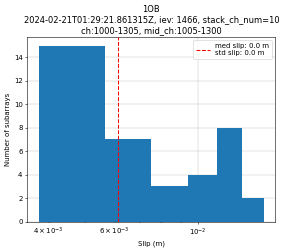

In [68]:
#%%% Stress drop
reload(ut)
# =============================================================================
show_plot=True

# =============================================================================
# Seismic moment (N.m)
m0_list=ut.seismic_moment(Omega0=Omega0_list,rho=2790,c=src_vp,R=mid_dis_m_list,Ur=0.52)
# Spectral stress drop (MPa)
strdrop_list=ut.stress_drop(m0=m0_list,fc=fc_list,c=src_vp/1.78,k=0.38)

# Moment magnitude (Note: This is not a suitable magnitude for M<3 events. This is just for an intuitive reference.)
Mw_list=ut.m02Mw_Nm(m0_list)

#% Source radius and slip
src_radius_list=ut.fc_2_src_radius(fc_list,k=0.38,beta=src_vp/1.78)
slip_list=ut.slip_from_m0(m0_list,r=src_radius_list,mu=30e9) # Mu here is based on the well log

if show_plot:
    def plot_src_param_result(x, legend, xlabel,logx=True):
    
        vm1=np.nanpercentile(x,0)
        vm2=np.nanpercentile(x,100)
        x=np.where((x>=vm1)&(x<=vm2),x,np.nan)
        fig,ax=plt.subplots()
        plt.hist(x,  zorder=3,bins=6)#,bins=log_bins)
        ax.axvline(np.nanmedian(x),ls='dashed',color='r',
                   label=legend,zorder=4)
        if logx:
            plt.xscale('log')
        # plt.xlim([1,100])
        plt.grid(True,lw=0.5)
        plt.title('%s\n%s, iev: %s, stack_ch_num=%d\nch:%s-%s, mid_ch:%s-%s'%(
            which_well,t0,iev,stack_ch_num,ch0_list[0],ch0_list[-1]+stack_ch_num,mid_ch_list[0],mid_ch_list[-1]))
        plt.xlabel(xlabel)
        plt.ylabel('Number of subarrays')
        plt.legend()
        plt.show()

    plot_src_param_result(strdrop_list, 
                          'med $\Delta\sigma$: %.01f MPa'%np.nanmedian(strdrop_list)+'\n'+\
                   'std $\Delta\sigma$: %.01f MPa'%np.nanstd(strdrop_list), '$\Delta\sigma$ (MPa)')

    plot_src_param_result(m0_list, 
                          'med m0: %.01f N.m'%np.nanmedian(m0_list)+'\n'+\
                   'std m0: %.01f N.m'%np.nanstd(m0_list), 'log_10(m0) (N.m)')

    plot_src_param_result(Mw_list, 
                      'med Mw: %.01f'%np.nanmedian(Mw_list)+'\n'+\
               'std Mw: %.01f'%np.nanstd(Mw_list), 'Mw')
    plot_src_param_result(src_radius_list, 
                  'med src_radius: %.01f m'%np.nanmedian(src_radius_list)+'\n'+\
           'std src_radius: %.01f m'%np.nanstd(src_radius_list), 'Source radius (m)')
    plot_src_param_result(slip_list, 
              'med slip: %.01f m'%np.nanmedian(slip_list)+'\n'+\
       'std slip: %.01f m'%np.nanstd(slip_list), 'Slip (m)')

# Final note

I wrap 2. up as a function and run for all events in the catalog. Then, I have:

* iev_events: evid of all events in the format of t0.strftime('%Y%m%d%H%M%S_%f')
* fc_events: fc results for all events and all channel stacks 
* m0_events: m0 results for all events and all channel stacks 
* ...

* std_fc_events: fc standard deviation for all events and all channel stacks 
* ...

I use iev_events to check the incident angle files in catalog/tt_inc_P to throw out measurements with large incident angles. There are many other quality controls that can be implemented (e.g., only include low std fittings.. etc), if these QC are not considered previously.
